# Predicting Protein Prediction

Consider as starting point for this exercise a UCI Protein Structure. The dataset comes from the Critical Assessment of protein Structure Prediction experiments (CASP), which is a recurrent (biannual) initiative to predict protein structure from experimental data.

The dataset consists of roughly 45k entries with nine features and one target. 

The features essentially are calculated physicochemical descriptors:
- F1: Total surface area (Approximate exposed surface of the protein)
- F2: Non-polar exposed area (Hydrophobic surface)
- F3: Fraction of exposed nonpolar area (Ratio of hydrophobic and total surface)
- F4: Residue surface exposure (How much amino acids are exposed)
- F5: Secondary structure agreement (Measures consistency with expected structures (α-helices, β-sheets))
- F6: Pairwise distance features (Encodes distances between residues)
- F7: Compactness / packing (How tightly folded the protein is)
- F8: Structural energy-related feature (Proxy for physical plausibility)
- F9: Additional geometric descriptor (Captures global structure properties)

The target is the RMSD (Root Mean Squared Deviation) that describes the deviation of the predicted from the true protein structure. 

The aim of the exercise is to build a model to predict how accurate predicted structures would be based on calculated descriptors.

#### Tasks:
1) The data is somewhat abstract. Inspect it to see what can be expected of a potential model.
2) Create feature matrix and target vector.
3) Choose one Regression ML model, build it and optimise (consider scaling if the model class needs it)
4) Take note of the training and test time for your model (approximation is enough)
5) Whatever model you end up using, try to optimise for accuracy and minimal overfitting, use **MSE** for evaluating your model!
6) Respond to the discussion points.

#### Note:
Feel free in your choice in model class, everything covered in the course so far is on the table. You don't need to compare different ones, we will do that with the compiled results of all assignments.

In [17]:
# complete imports if needed for your solution
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


Load and investigate the data

In [18]:
df = pd.read_csv("CASP.csv")
df.head()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45730 entries, 0 to 45729
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    45730 non-null  float64
 1   F1      45730 non-null  float64
 2   F2      45730 non-null  float64
 3   F3      45730 non-null  float64
 4   F4      45730 non-null  float64
 5   F5      45730 non-null  float64
 6   F6      45730 non-null  float64
 7   F7      45730 non-null  float64
 8   F8      45730 non-null  int64  
 9   F9      45730 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 3.5 MB


None

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
count,45730.000000,45730.000000,45730.000000,45730.000000,45730.000000,4.573000e+04,45730.000000,45730.000000,45730.000000,45730.000000
mean,7.748528,9871.596995,3017.367175,0.302392,103.492433,1.368299e+06,145.638061,3989.755990,69.975071,34.523664
std,6.118312,4058.138034,1464.324663,0.062886,55.424985,5.640367e+05,69.999230,1993.574575,56.493443,5.979755
min,0.000000,2392.050000,403.500000,0.092500,10.310100,3.194902e+05,31.970400,0.000000,0.000000,15.228000
25%,2.305000,6936.680000,1979.045000,0.258740,63.563900,9.535912e+05,94.757500,3165.322500,31.000000,30.424725
50%,5.030000,8898.805000,2668.155000,0.300150,87.740800,1.237219e+06,126.176000,3840.170000,54.000000,35.299300
75%,13.379000,12126.150000,3786.410000,0.342890,133.646750,1.690920e+06,181.468500,4644.192500,91.000000,38.870800
max,20.999000,40034.900000,15312.000000,0.577690,369.317000,5.472011e+06,598.408000,105948.170000,350.000000,55.300900


RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      0
F9      0
dtype: int64

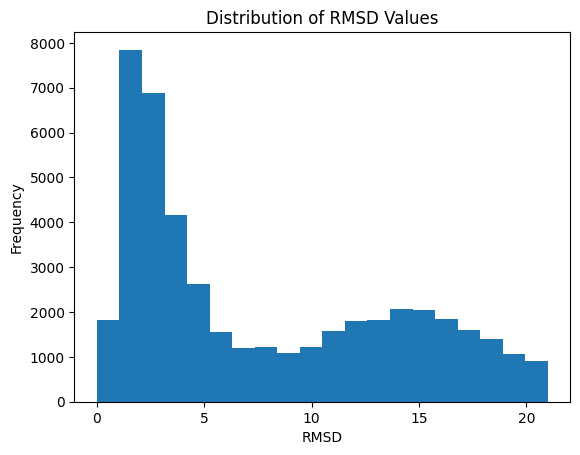

In [19]:
# investigate the data
display(df.info())
display(df.describe())
display(df.isnull().sum())

plt.hist(df['RMSD'], bins=20)
plt.xlabel('RMSD')
plt.ylabel('Frequency')
plt.title('Distribution of RMSD Values')
plt.show()

Build feature matrix and target vector. Add scaling if needed for your model.

In [20]:
# target variable is RMSD, features are the rest of the columns
X = df.drop(columns=['RMSD'])
y = df['RMSD']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

Choose a Regression model, build, train and optimise

In [22]:
class MyDataFromDF(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.to_numpy(), dtype=torch.float32)
        self.y = torch.tensor(y.to_numpy(), dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [23]:
class ProteinNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, dropout):
        super(ProteinNN, self).__init__()
        layers = []
        in_size = input_size
        for h in hidden_sizes:
            layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(p=dropout)]
            in_size = h
        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


early stopping function:

In [24]:
def train_model(model, train_loader, test_loader, criterion, optimizer,
                max_epochs=300, patience=15):
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y in test_loader:
                val_loss += criterion(model(x), y).item()
        val_loss /= len(test_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            break

    model.load_state_dict(best_model_state)
    return model, best_val_loss, epoch + 1

Evaluate your best model (MSE). Take note of training and test time (approximate).

In [25]:
hidden_configs = {
    '2L_small':  [32, 16],
    '2L_medium': [64, 32],
    '2L_large':  [128, 64],
    '3L_small':  [32, 32, 16],
    '3L_medium': [64, 64, 32],
    '3L_large':  [128, 128, 64],
}
learning_rates = [0.001, 0.01, 0.0001]
DROPOUT    = 0.2
BATCH_SIZE = 256
INPUT_SIZE = X_train.shape[1]


run a grid search manually:

In [ ]:
results = []

for lr in learning_rates:
    for config_name, hidden_sizes in hidden_configs.items():

        train_loader = DataLoader(MyDataFromDF(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
        test_loader  = DataLoader(MyDataFromDF(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

        model     = ProteinNN(INPUT_SIZE, hidden_sizes, DROPOUT)
        criterion = nn.MSELoss()
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4) # weight decay is a regularization parameter which helps prevent overfitting by adding a penalty to large weights

        start = time.time()
        model, best_val_mse, epochs_run = train_model(model, train_loader, test_loader, criterion, optimizer)
        elapsed = time.time() - start

        # train MSE for overfitting check
        model.eval()
        train_loss = 0.0
        with torch.no_grad():
            for x, y_batch in train_loader:
                train_loss += criterion(model(x), y_batch).item()
        train_mse = train_loss / len(train_loader)

        results.append({
            'config':    config_name,
            'lr':        lr,
            'train_MSE': round(train_mse, 4),
            'val_MSE':   round(best_val_mse, 4),
            'epochs':    epochs_run,
            'time_s':    round(elapsed, 1),
        })
        print(f"{config_name} | lr={lr} | val_MSE={best_val_mse:.2f} | epochs={epochs_run} | {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values('val_MSE')
display(results_df)

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/Users/mircodill/DSA104/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([256])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/mircodill/DSA104/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([232])) that is different to the input size (torch.Size([232, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/mircodill/DSA104/.venv/lib/python3.12/site-packages/torch/nn/modules/lo

2L_small | lr=0.001 | val_MSE=37.64 | epochs=109 | 57.9s
2L_medium | lr=0.001 | val_MSE=37.64 | epochs=68 | 35.3s
2L_large | lr=0.001 | val_MSE=37.64 | epochs=36 | 21.2s
3L_small | lr=0.001 | val_MSE=37.64 | epochs=74 | 36.0s
3L_medium | lr=0.001 | val_MSE=37.64 | epochs=41 | 21.0s
3L_large | lr=0.001 | val_MSE=37.65 | epochs=27 | 17.2s
2L_small | lr=0.01 | val_MSE=37.64 | epochs=35 | 17.0s
2L_medium | lr=0.01 | val_MSE=37.64 | epochs=41 | 20.4s
2L_large | lr=0.01 | val_MSE=37.64 | epochs=32 | 17.1s
3L_small | lr=0.01 | val_MSE=37.64 | epochs=57 | 33.1s
3L_medium | lr=0.01 | val_MSE=37.64 | epochs=35 | 17.2s
3L_large | lr=0.01 | val_MSE=37.64 | epochs=50 | 37.5s
2L_small | lr=0.0001 | val_MSE=37.66 | epochs=172 | 91.5s
2L_medium | lr=0.0001 | val_MSE=37.65 | epochs=103 | 51.3s
2L_large | lr=0.0001 | val_MSE=37.65 | epochs=105 | 56.6s
3L_small | lr=0.0001 | val_MSE=37.66 | epochs=99 | 51.4s
3L_medium | lr=0.0001 | val_MSE=37.65 | epochs=83 | 45.1s
3L_large | lr=0.0001 | val_MSE=37.65 | 

,config,lr,train_MSE,val_MSE,epochs,time_s
7,2L_medium,0.0100,37.3888,37.6397,41,20.4
0,2L_small,0.0010,37.3852,37.6398,109,57.9
10,3L_medium,0.0100,37.3947,37.6398,35,17.2
9,3L_small,0.0100,37.3832,37.6398,57,33.1
11,3L_large,0.0100,37.3838,37.6398,50,37.5
6,2L_small,0.0100,37.3876,37.6399,35,17.0
3,3L_small,0.0010,37.3871,37.6399,74,36.0
8,2L_large,0.0100,37.5263,37.6403,32,17.1
4,3L_medium,0.0010,37.4724,37.6406,41,21.0
1,2L_medium,0.0010,37.3912,37.6413,68,35.3


all quite similar, indicates that the hyperparameters are not really the bottleneck of the problem and model.

#### Discussion points
1) Discuss your choice of model class.
2) How did you optimise your model? How did the best model perform?
3) How much time was needed for training the model and evaluations (approximation is enough)?
4) What limitations or shortcomings did you identify? What would be ideas to remedy or circumvent them?
5) In all its abstraction, what do the predictions of your model tell you?

1. neural network with pytorch. good fit for a dataset of this size with enough data to train a NN. no assumptions about linearity, can capture complex relationships between the descriptors and RMSD. scaling not strictly needed usually for NN, but still applied to prevent imbalances between features 6 orders of magnitude apart.

2. tested 18 combinations of hidden layer configs (2 vs 3 layers, small/medium/large) and learning rates (0.0001, 0.001, 0.01), with fixed dropout (0.2) and batch size (256). early stopping with patience=15 prevented overfitting and kept runtimes short. best model: 3L_medium [64, 64, 32] with lr=0.01, val_MSE=37.64, converged in 35 epochs (~17s). notably, all configs converged to nearly identical val_MSE, suggesting the feature set is the limiting factor, not the architecture. runtime was the most notable difference between the configs.

3. grid search over 18 configs took ~11-12 minutes total. individual runs ranged from 17s to ~90s.

4. the near-identical MSE across all architectures suggests the features are limiting the predictive power for RMSD in my case. the model hits a ceiling regardless of complexity. adding more informative features could help more than tuning the model further.

5. the model predicts how far off a computational protein structure prediction is from the true structure, based on physicochemical descriptors. a low predicted RMSD means the structure is likely to be reliable, a high score means poor prediction.